In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv(r"e:\Final\IBM_HR.csv")

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
print(df.duplicated().sum())

0


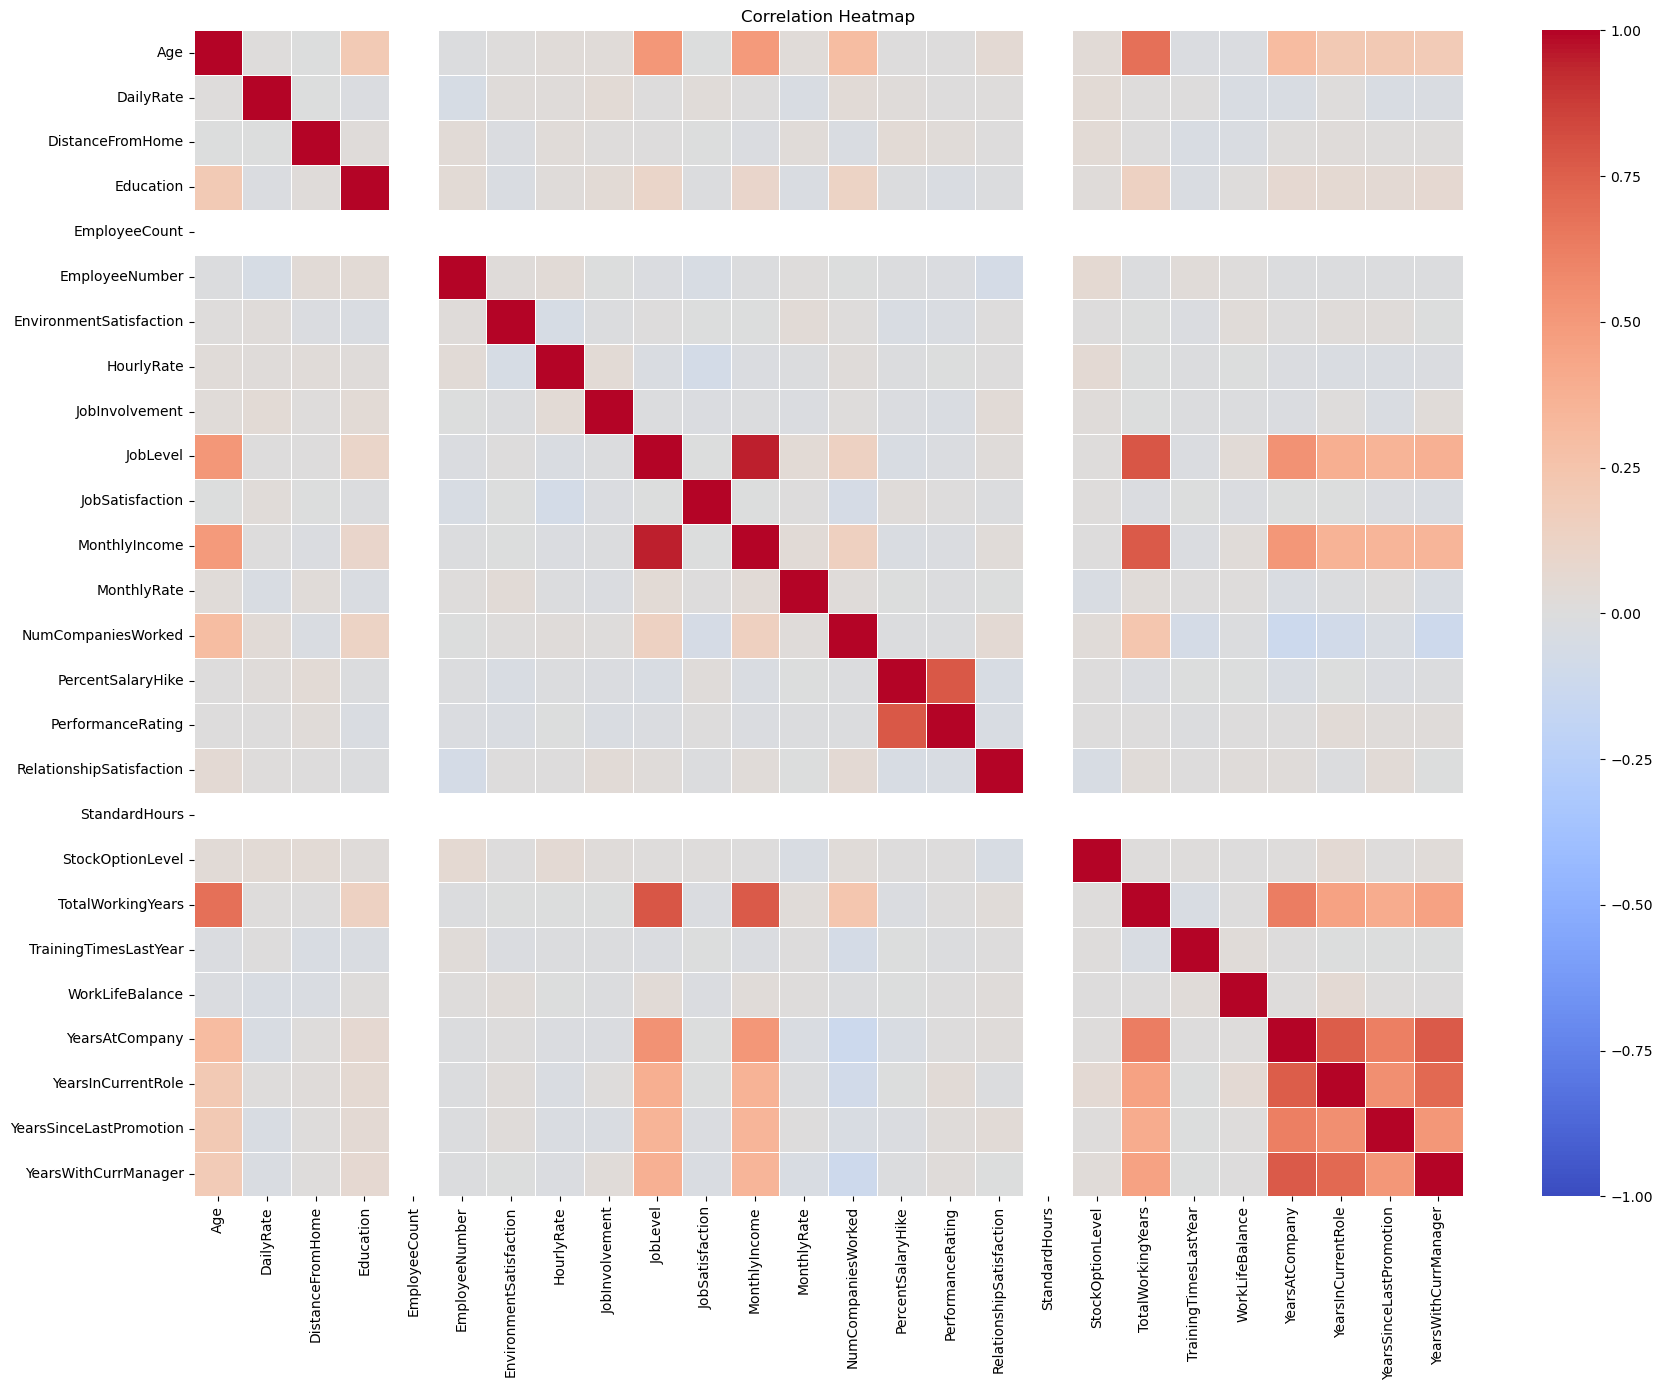

In [6]:
# Correlation heatmap for numeric columns only
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# Min-Max normalization of numeric columns to the range [0, 1]
normalized_numeric_df = numeric_df.apply(
    lambda column: (column - column.min()) / (column.max() - column.min())
    if column.max() != column.min()
    else 0
)

normalized_numeric_df.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.547619,0.715820,0.000000,0.25,0,0.000000,0.333333,0.914286,0.666667,0.25,...,0.000000,0,0.000000,0.200,0.0,0.000000,0.15,0.222222,0.000000,0.294118
1,0.738095,0.126700,0.250000,0.00,0,0.000484,0.666667,0.442857,0.333333,0.25,...,1.000000,0,0.333333,0.250,0.5,0.666667,0.25,0.388889,0.066667,0.411765
2,0.452381,0.909807,0.035714,0.25,0,0.001451,1.000000,0.885714,0.333333,0.00,...,0.333333,0,0.000000,0.175,0.5,0.666667,0.00,0.000000,0.000000,0.000000
3,0.357143,0.923407,0.071429,0.75,0,0.001935,1.000000,0.371429,0.666667,0.00,...,0.666667,0,0.000000,0.200,0.5,0.666667,0.20,0.388889,0.200000,0.000000
4,0.214286,0.350036,0.035714,0.00,0,0.002903,0.000000,0.142857,0.666667,0.00,...,1.000000,0,0.333333,0.150,0.5,0.666667,0.05,0.111111,0.133333,0.117647


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Attrition")
y = df["Attrition"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (1176, 34) (1176,)
Test set: (294, 34) (294,)


Accuracy: 0.8605442176870748

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



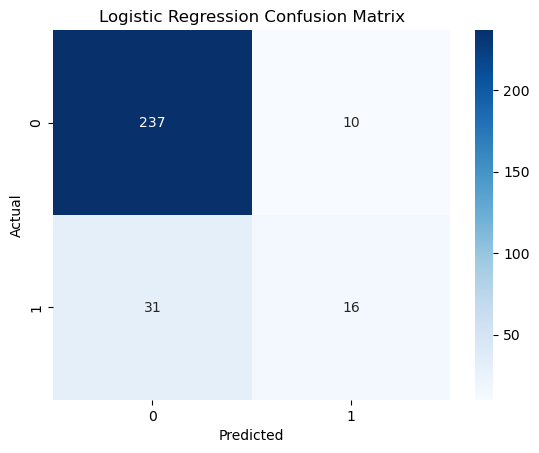

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

categorical_columns = X.select_dtypes(include=["object"]).columns
numeric_columns = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

SVM Accuracy: 0.8639455782312925

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.77      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.82      0.60      0.63       294
weighted avg       0.85      0.86      0.83       294



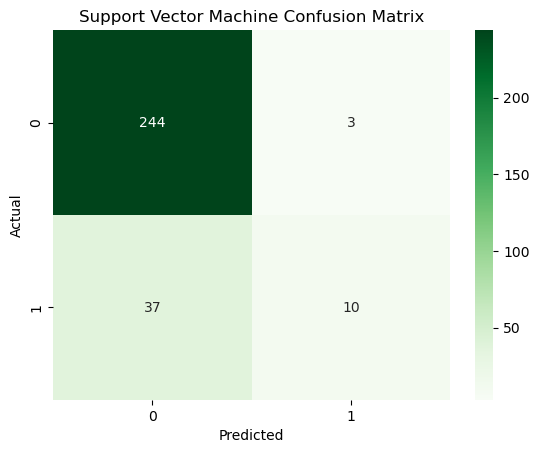

In [10]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ]
)

svm_model.fit(X_train, y_train)

svm_y_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_y_pred))

sns.heatmap(
    confusion_matrix(y_test, svm_y_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

Mean Squared Error: 0.11335193161808309
R² Score: 0.15602656892577915

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.75      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.85      0.86      0.82       294



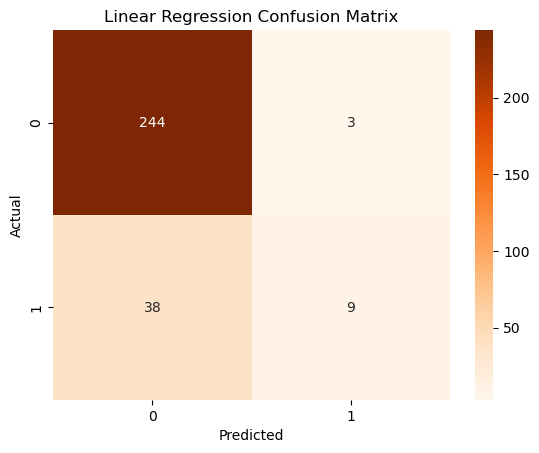

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_regression_model.fit(X_train, y_train)

# Continuous predictions
linear_y_pred = linear_regression_model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, linear_y_pred))
print("R² Score:", r2_score(y_test, linear_y_pred))

# Convert regression output to binary predictions
linear_class_pred = (linear_y_pred >= 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, linear_class_pred))

sns.heatmap(
    confusion_matrix(y_test, linear_class_pred),
    annot=True,
    fmt="d",
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear Regression Confusion Matrix")
plt.show()

In [12]:
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone

# Feature selection using L1-regularized logistic regression
feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        random_state=42,
        max_iter=1000
    ),
    threshold="median"
)

selected_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("feature_selector", feature_selector),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

selected_model.fit(X_train, y_train)

selected_y_pred = selected_model.predict(X_test)

print("Selected-feature model accuracy:",
      accuracy_score(y_test, selected_y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, selected_y_pred))

# Display selected features
feature_names = selected_model.named_steps["preprocessor"].get_feature_names_out()
selected_features = feature_names[
    selected_model.named_steps["feature_selector"].get_support()
]

print("Selected features:", len(selected_features))
print(*selected_features, sep="\n")

Selected-feature model accuracy: 0.8605442176870748

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Selected features: 55
numeric__Age
numeric__DailyRate
numeric__DistanceFromHome
numeric__Education
numeric__EmployeeCount
numeric__EmployeeNumber
numeric__EnvironmentSatisfaction
numeric__HourlyRate
numeric__JobInvolvement
numeric__JobLevel
numeric__JobSatisfaction
numeric__MonthlyIncome
numeric__MonthlyRate
numeric__NumCompaniesWorked
numeric__PercentSalaryHike
numeric__PerformanceRating
numeric__RelationshipSatisfaction
numeric__StandardHours
numeric__StockOptionLevel
numeric__TotalWorkingYears
numeric__TrainingTimesLastYear
numeric__WorkLifeBalance
numeric__YearsAtCompany
numeric__Years

In [13]:
# Identify selected transformed features from the fitted feature selector
preprocessor_fitted = selected_model.named_steps["preprocessor"]
feature_selector_fitted = selected_model.named_steps["feature_selector"]

transformed_features = preprocessor_fitted.get_feature_names_out()
selected_mask = feature_selector_fitted.get_support()
selected_transformed_features = transformed_features[selected_mask]

# Map transformed features back to original dataframe columns
selected_original_columns = []

for column in X.columns:
    if column in numeric_columns:
        transformed_name = f"numeric__{column}"
        if transformed_name in selected_transformed_features:
            selected_original_columns.append(column)
    else:
        prefix = f"categorical__{column}_"
        if any(feature.startswith(prefix) for feature in selected_transformed_features):
            selected_original_columns.append(column)

# Retain the target column
selected_columns = ["Attrition"] + selected_original_columns
df = df[selected_columns].copy()

# Update numeric data used by later cells
numeric_df = df.select_dtypes(include=["number"])

print("Remaining columns:", len(df.columns))
print(df.columns.tolist())

Remaining columns: 35
['Attrition', 'Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [14]:
df.to_csv("Cleaned_IBM_HR.csv", index=False)
print("Data exported successfully.")

Data exported successfully.
